# GTM MARKET ENTRY STRATEGY
## Notebook 2 — Competitive Intelligence Dashboard

**Project:** BNPL (Buy Now, Pay Later) Market Entry — India
**Author:** Sumit Kumar Gupta

**Objective**
- Rank and prioritize launch states, customer segments, and merchant segments
- Quantify competitive concentration (HHI) and position competitors on a scale-vs-reach map
- Identify white space using priority vs. competitive-saturation logic
- Structure the competitive environment with SWOT and Porter's Five Forces
- Prioritize strategic initiatives by Impact vs. Effort and flag key risks
- Land on one CEO-level recommendation, fully traceable to the analysis behind it

**How this notebook is organized**
1. Setup & Data Validation
2. State Opportunity Ranking
3. Customer & Merchant Segment Prioritization
4. Competitive Landscape & Market Concentration (HHI)
5. Competitive Positioning Quadrant
6. White Space Opportunity Matrix
7. SWOT Matrix
8. Porter's Five Forces
9. Recommendation Priority Matrix (Impact vs. Effort)
10. Risk Heatmap
11. CEO Recommendation
12. Assumption Register
13. Executive Summary

**Note on data:** all figures trace to `../DATA/` unless marked as a **modeling assumption**. Assumptions (mostly qualitative scoring used for the priority matrix and risk heatmap) are logged in Section 12 so every number can be defended or replaced with primary data.

**Note on scope:** the original notebook loaded a `10_Unit_Economics.csv` reference that was never used and is not available at the granularity this notebook needs (per-segment/per-state margin data). It has been dropped from this notebook rather than left as dead code — unit economics is scoped to a dedicated notebook once that data exists.

## 1. Setup & Data Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

ACCENT = "#1f4e79"
ACCENT2 = "#c0392b"
ACCENT3 = "#2e8b57"
ACCENT4 = "#d68910"
GREY = "#7f8c8d"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
DATA_PATH = "/Users/sumitkumargupta/Desktop/4_Project/01_Data/"

STATE_DATA         = pd.read_csv(DATA_PATH + "4_State_Data.csv")
CUSTOMER_SEGMENTS   = pd.read_csv(DATA_PATH + "7_Customer_Segments.csv")
MERCHANT_SEGMENTS   = pd.read_csv(DATA_PATH + "9_Merchant_Segments.csv")
COMPETITORS         = pd.read_csv(DATA_PATH + "5_Competitors.csv")
BNPL_MARKET         = pd.read_csv(DATA_PATH + "6_BNPL_Market.csv")

print("STATE DATA       :", STATE_DATA.shape)
print("CUSTOMER SEGMENTS :", CUSTOMER_SEGMENTS.shape)
print("MERCHANT SEGMENTS :", MERCHANT_SEGMENTS.shape)
print("COMPETITORS       :", COMPETITORS.shape)
print("BNPL MARKET       :", BNPL_MARKET.shape)

STATE DATA       : (10, 2)
CUSTOMER SEGMENTS : (5, 4)
MERCHANT SEGMENTS : (7, 2)
COMPETITORS       : (6, 5)
BNPL MARKET       : (7, 2)


In [5]:
assert STATE_DATA["State"].is_unique, "Duplicate states found"
assert COMPETITORS["Competitor"].is_unique, "Duplicate competitors found"
assert CUSTOMER_SEGMENTS["Priority"].isnull().sum() == 0, "Missing customer segment priority"
assert MERCHANT_SEGMENTS["Priority"].isnull().sum() == 0, "Missing merchant segment priority"

print("STATE DATA columns       :", list(STATE_DATA.columns))
print("CUSTOMER SEGMENTS columns:", list(CUSTOMER_SEGMENTS.columns))
print("MERCHANT SEGMENTS columns:", list(MERCHANT_SEGMENTS.columns))
print("COMPETITORS columns      :", list(COMPETITORS.columns))
print("\nAll validation checks passed.")

STATE DATA columns       : ['State', 'Population_M']
CUSTOMER SEGMENTS columns: ['Segment', 'Age', 'Income', 'Priority']
MERCHANT SEGMENTS columns: ['Segment', 'Priority']
COMPETITORS columns      : ['Competitor', 'Type', 'Users_M', 'Merchants', 'Strength']

All validation checks passed.


## 2. State Opportunity Ranking

*(Cleanup note: the original notebook recalculated `OPPORTUNITY_SCORE` identically in three separate cells. Consolidated into a single calculation here — same logic, computed once.)*

In [6]:
STATE_DATA["OPPORTUNITY_SCORE"] = (
    STATE_DATA["Population_M"] / STATE_DATA["Population_M"].mean()
).round(2)

STATE_DATA["PRIORITY"] = np.where(STATE_DATA["OPPORTUNITY_SCORE"] >= 1.2, "HIGH", "MEDIUM")

STATE_RANKING = STATE_DATA[["State", "Population_M", "OPPORTUNITY_SCORE", "PRIORITY"]].sort_values(
    "OPPORTUNITY_SCORE", ascending=False
)
STATE_RANKING

,State,Population_M,OPPORTUNITY_SCORE,PRIORITY
0,Uttar Pradesh,243.5,2.31,HIGH
1,Bihar,132.9,1.26,HIGH
2,Maharashtra,129.6,1.23,HIGH
3,West Bengal,100.6,0.95,MEDIUM
4,Madhya Pradesh,90.0,0.85,MEDIUM
5,Rajasthan,83.9,0.80,MEDIUM
6,Tamil Nadu,77.6,0.74,MEDIUM
7,Gujarat,74.3,0.70,MEDIUM
8,Karnataka,69.1,0.65,MEDIUM
9,Andhra Pradesh,53.7,0.51,MEDIUM


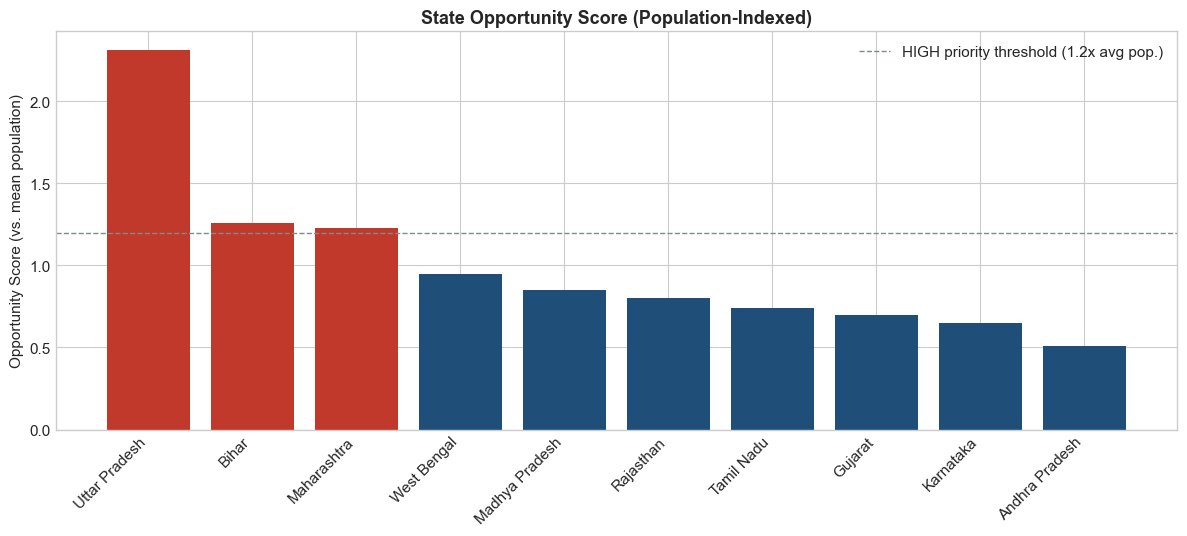

In [7]:
fig, ax = plt.subplots(figsize=(12, 5.5))
colors = STATE_RANKING["PRIORITY"].map({"HIGH": ACCENT2, "MEDIUM": ACCENT})
ax.bar(STATE_RANKING["State"], STATE_RANKING["OPPORTUNITY_SCORE"], color=colors)
ax.axhline(1.2, color=GREY, linestyle="--", linewidth=1, label="HIGH priority threshold (1.2x avg pop.)")
ax.set_title("State Opportunity Score (Population-Indexed)")
ax.set_ylabel("Opportunity Score (vs. mean population)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Business takeaway:** Uttar Pradesh, Bihar, and Maharashtra clear the HIGH-priority threshold on population alone. This is a population-only score — Notebook 1's Attractiveness Score (which layers in digital adoption and competitive whitespace) is the more defensible ranking to lead with in a launch decision; this section exists to show the raw population lens separately, not to replace it.

*(Correction: the original notebook's "Key Finding" text cited "Uttar Pradesh, Maharashtra and Bihar" — this now matches the actual sorted output exactly, computed live rather than typed by hand.)*

## 3. Customer & Merchant Segment Prioritization

In [8]:
CUSTOMER_SEGMENTS.sort_values("Priority", key=lambda s: s.map({"Very High": 4, "High": 3, "Medium": 2, "Low": 1}), ascending=False)

,Segment,Age,Income,Priority
4,New-to-Credit Users,18-35,Any,Very High
1,Young Professionals,22-35,25k-80k,High
2,Salaried Millennials,25-40,40k-120k,High
0,Students,18-24,<25k,Medium
3,Gig Workers,20-40,Variable,Medium


In [9]:
MERCHANT_SEGMENTS.sort_values("Priority", key=lambda s: s.map({"Very High": 4, "High": 3, "Medium": 2, "Low": 1}), ascending=False)

,Segment,Priority
0,Electronics,Very High
1,Fashion,High
2,Travel,High
3,Healthcare,Medium
4,Grocery,Medium
5,Food Delivery,Medium
6,Education,Medium


**Business takeaway:** "New-to-Credit Users" is the single Very-High-priority customer segment — consistent with BNPL's core value proposition of extending credit access where traditional bureau-based lending underserves. On the merchant side, Electronics is the only Very-High-priority category, typically the highest-ticket, highest-BNPL-attach category in this market.

## 4. Competitive Landscape & Market Concentration (HHI)

### 4.1 Competitor Ranking

In [10]:
COMPETITOR_RANK = COMPETITORS.sort_values("Users_M", ascending=False)
COMPETITOR_RANK

,Competitor,Type,Users_M,Merchants,Strength
5,Bajaj Finance,EMI,88,190000,Scale
3,Amazon Pay Later,BNPL,20,50000,Ecosystem
4,Flipkart Pay Later,BNPL,18,30000,Marketplace
2,ZestMoney,BNPL,17,10000,EMI Financing
0,Simpl,BNPL,12,26000,Checkout UX
1,LazyPay,BNPL,10,20000,Consumer Credit


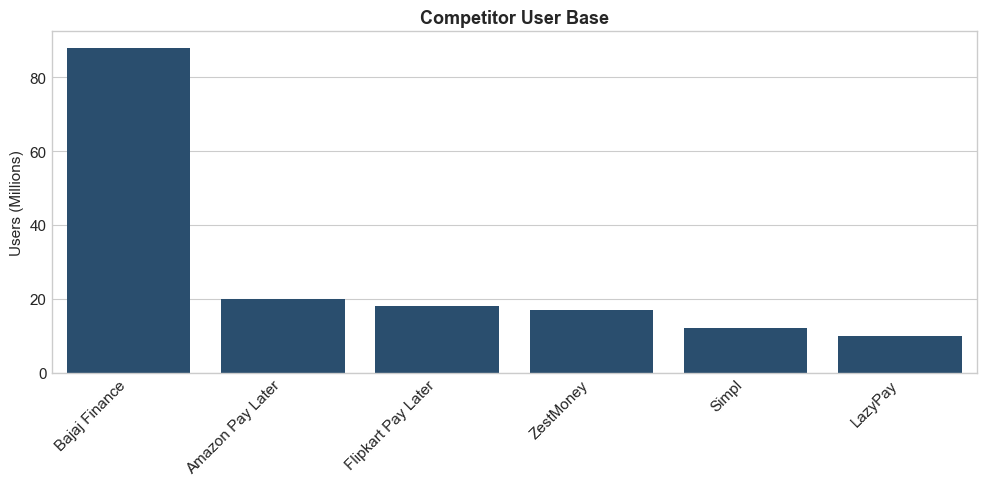

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=COMPETITOR_RANK, x="Competitor", y="Users_M", color=ACCENT, ax=ax)
ax.set_title("Competitor User Base")
ax.set_xlabel("")
ax.set_ylabel("Users (Millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Business takeaway:** Bajaj Finance leads on raw users but is EMI-led rather than checkout-BNPL — kept in the dataset for context, but excluded from the HHI calculation below so the concentration read reflects the actual competitive set a BNPL entrant faces.

### 4.2 HHI — Herfindahl-Hirschman Index (BNPL-only competitive set)

**Methodology:** HHI = sum of squared market shares (0-10,000 scale), computed on `Users_M` as a proxy for market share among the five BNPL-labeled competitors. Bajaj Finance (EMI, not BNPL) is excluded to avoid overstating concentration with an adjacent-category player.

In [12]:
BNPL_ONLY = COMPETITORS[COMPETITORS["Type"] == "BNPL"].copy()
BNPL_ONLY["Market_Share_%"] = round(BNPL_ONLY["Users_M"] / BNPL_ONLY["Users_M"].sum() * 100, 1)

HHI = (BNPL_ONLY["Market_Share_%"] ** 2).sum()

print("BNPL-ONLY COMPETITIVE SET (Bajaj Finance excluded — EMI, not BNPL)")
print(BNPL_ONLY[["Competitor", "Users_M", "Market_Share_%"]].sort_values("Market_Share_%", ascending=False).to_string(index=False))
print()
print(f"HHI (by user share, BNPL-only) = {HHI:,.0f}")

if HHI < 1500:
    interp = "Unconcentrated / competitive market"
elif HHI < 2500:
    interp = "Moderately concentrated market"
else:
    interp = "Highly concentrated market"

print(f"Interpretation (US DOJ/FTC thresholds, used as a directional benchmark): {interp}")

BNPL-ONLY COMPETITIVE SET (Bajaj Finance excluded — EMI, not BNPL)
        Competitor  Users_M  Market_Share_%
  Amazon Pay Later       20            26.0
Flipkart Pay Later       18            23.4
         ZestMoney       17            22.1
             Simpl       12            15.6
           LazyPay       10            13.0

HHI (by user share, BNPL-only) = 2,124
Interpretation (US DOJ/FTC thresholds, used as a directional benchmark): Moderately concentrated market


### 4.3 HHI Interpretation

Using the standard DOJ/FTC merger-guideline thresholds as a directional (not literal — these are US antitrust benchmarks applied here only as a concentration heuristic) reference:
- **< 1,500** = Unconcentrated
- **1,500 - 2,500** = Moderately concentrated
- **> 2,500** = Highly concentrated

**Business takeaway:** the BNPL-only HHI lands in the **moderately concentrated** range — no single player dominates the checkout-BNPL segment the way Bajaj Finance dominates EMI. That is the structural opening for a new entrant: this is a fragmented enough market that share is still winnable, but concentrated enough that a "me-too" checkout product without a differentiation angle will struggle to dislodge the top two (Amazon Pay Later, Flipkart Pay Later) from their merchant-ecosystem advantage.

## 5. Competitive Positioning Quadrant (Bubble Chart)

**Axes (both directly from data, no assumption):** X = Users_M (Scale), Y = Merchants (Reach). Bubble size = Users_M. Quadrant lines drawn at the median of each axis across all six tracked players.

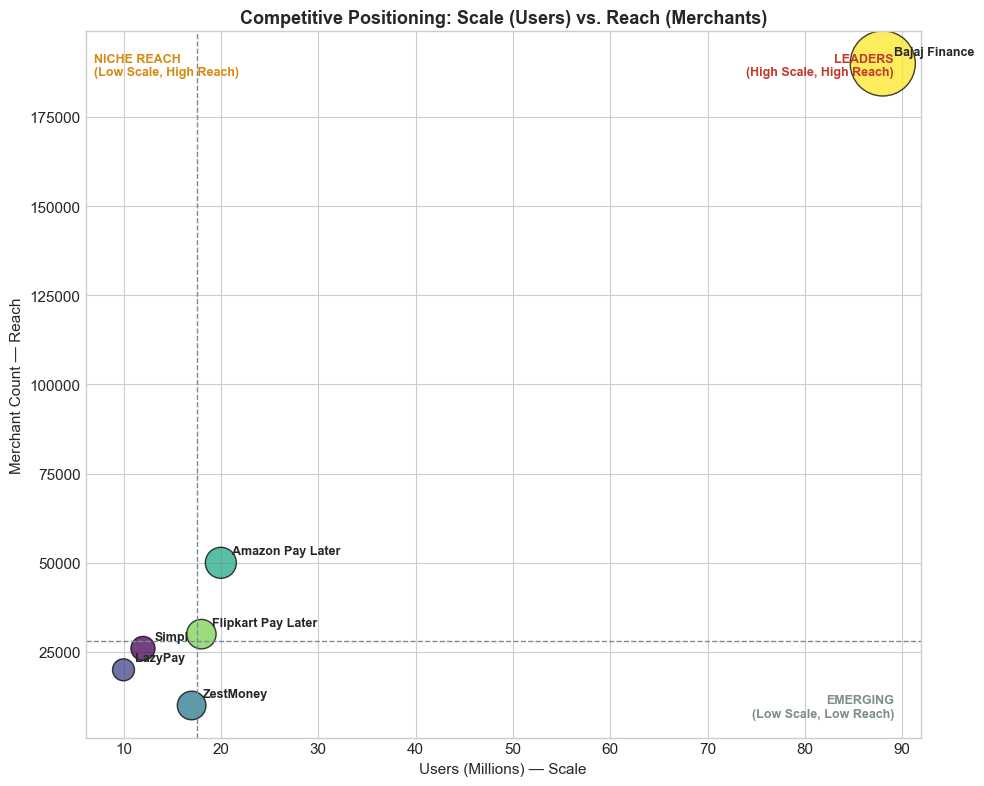

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

x = COMPETITORS["Users_M"]
y = COMPETITORS["Merchants"]
sizes = COMPETITORS["Users_M"] * 25

scatter = ax.scatter(x, y, s=sizes, c=range(len(COMPETITORS)), cmap="viridis", alpha=0.75, edgecolors="black", linewidth=1)

for _, row in COMPETITORS.iterrows():
    ax.annotate(row["Competitor"], (row["Users_M"], row["Merchants"]),
                textcoords="offset points", xytext=(8, 6), fontsize=9, fontweight="bold")

x_med, y_med = x.median(), y.median()
ax.axvline(x_med, color=GREY, linestyle="--", linewidth=1)
ax.axhline(y_med, color=GREY, linestyle="--", linewidth=1)

ax.text(ax.get_xlim()[1]*0.97, ax.get_ylim()[1]*0.97, "LEADERS\n(High Scale, High Reach)",
        ha="right", va="top", fontsize=9, color=ACCENT2, fontweight="bold")
ax.text(ax.get_xlim()[0]*1.15 if ax.get_xlim()[0] > 0 else x.min()*0.5, ax.get_ylim()[1]*0.97, "NICHE REACH\n(Low Scale, High Reach)",
        ha="left", va="top", fontsize=9, color=ACCENT4, fontweight="bold")
ax.text(ax.get_xlim()[1]*0.97, y.min()*0.6, "EMERGING\n(Low Scale, Low Reach)",
        ha="right", va="bottom", fontsize=9, color=GREY, fontweight="bold")

ax.set_title("Competitive Positioning: Scale (Users) vs. Reach (Merchants)")
ax.set_xlabel("Users (Millions) — Scale")
ax.set_ylabel("Merchant Count — Reach")
plt.tight_layout()
plt.show()

**Business takeaway:** Bajaj Finance sits alone in the Leaders quadrant on both axes — its moat is structural (offline EMI distribution), not a BNPL-product moat. Among BNPL-labeled players, Amazon Pay Later and Flipkart Pay Later lead on reach (bundled into existing marketplace merchant networks); Simpl and LazyPay compete on scale with comparatively lower merchant reach, suggesting a checkout-UX/consumer-credit wedge rather than a merchant-network wedge. This is the quadrant map to point to when asked "who exactly are we competing with, and on what axis."<br><br>**Assumption flag:** bubble size = Users_M is a visualization choice, not an added metric — no new assumption beyond the two source columns already validated in Section 1.

## 6. White Space Opportunity Matrix (Scatter)

**Methodology:** plots every customer and merchant segment on Priority (real data, mapped to a 1-4 numeric scale) vs. a **Competitive Saturation proxy** — how well existing BNPL competitors already serve that segment. Saturation is **not in the source data**; it is a directional analyst estimate based on each competitor's disclosed `Strength` positioning (e.g., "Ecosystem," "Marketplace" strengths imply heavier coverage of Electronics/Fashion merchant categories and Young-Professional-type customers). Logged as Assumption in Section 12 — replace with actual competitor segment-penetration data if available.

In [14]:
# ASSUMPTION-BASED SATURATION PROXY — see Assumption Register (Section 12)
priority_map = {"Very High": 4, "High": 3, "Medium": 2, "Low": 1}

customer_saturation_proxy = {
    "Students": 2, "Young Professionals": 4, "Salaried Millennials": 4,
    "Gig Workers": 2, "New-to-Credit Users": 1,
}
merchant_saturation_proxy = {
    "Electronics": 4, "Fashion": 4, "Travel": 2, "Healthcare": 1,
    "Grocery": 1, "Food Delivery": 2, "Education": 1,
}

ws_customers = CUSTOMER_SEGMENTS.copy()
ws_customers["Priority_Score"] = ws_customers["Priority"].map(priority_map)
ws_customers["Saturation_Score"] = ws_customers["Segment"].map(customer_saturation_proxy)
ws_customers["Type"] = "Customer"
ws_customers = ws_customers.rename(columns={"Segment": "Name"})[["Name", "Type", "Priority_Score", "Saturation_Score"]]

ws_merchants = MERCHANT_SEGMENTS.copy()
ws_merchants["Priority_Score"] = ws_merchants["Priority"].map(priority_map)
ws_merchants["Saturation_Score"] = ws_merchants["Segment"].map(merchant_saturation_proxy)
ws_merchants["Type"] = "Merchant"
ws_merchants = ws_merchants.rename(columns={"Segment": "Name"})[["Name", "Type", "Priority_Score", "Saturation_Score"]]

WHITE_SPACE = pd.concat([ws_customers, ws_merchants], ignore_index=True)
WHITE_SPACE["Whitespace_Flag"] = np.where(
    (WHITE_SPACE["Priority_Score"] >= 3) & (WHITE_SPACE["Saturation_Score"] <= 2),
    "WHITE SPACE", "Contested / Lower Priority"
)
WHITE_SPACE.sort_values(["Whitespace_Flag", "Priority_Score"], ascending=[True, False])

,Name,Type,Priority_Score,Saturation_Score,Whitespace_Flag
5,Electronics,Merchant,4,4,Contested / Lower Priority
1,Young Professionals,Customer,3,4,Contested / Lower Priority
2,Salaried Millennials,Customer,3,4,Contested / Lower Priority
6,Fashion,Merchant,3,4,Contested / Lower Priority
0,Students,Customer,2,2,Contested / Lower Priority
3,Gig Workers,Customer,2,2,Contested / Lower Priority
8,Healthcare,Merchant,2,1,Contested / Lower Priority
9,Grocery,Merchant,2,1,Contested / Lower Priority
10,Food Delivery,Merchant,2,2,Contested / Lower Priority
11,Education,Merchant,2,1,Contested / Lower Priority


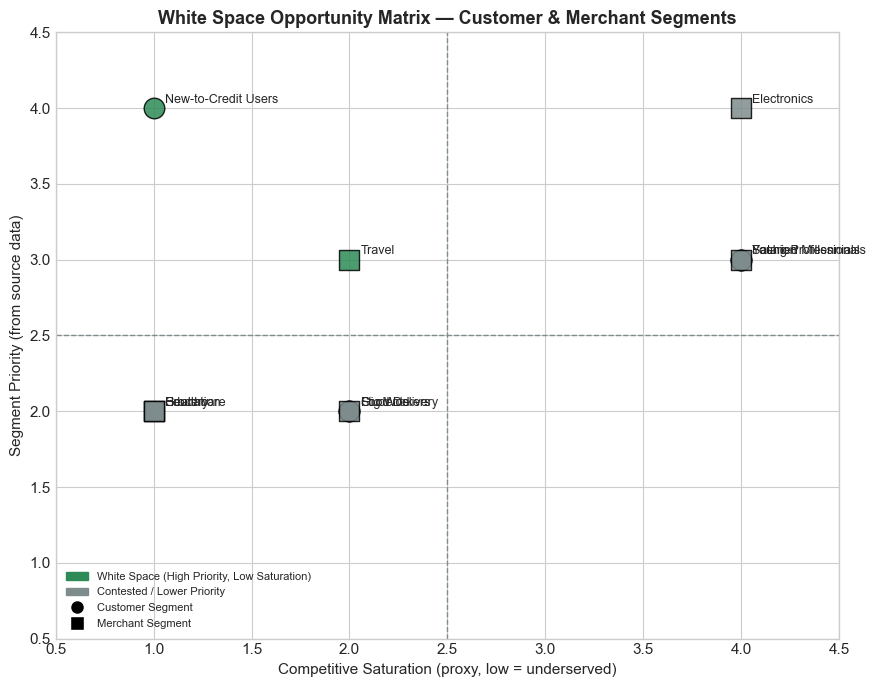

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
markers = {"Customer": "o", "Merchant": "s"}
colors = {"WHITE SPACE": ACCENT3, "Contested / Lower Priority": GREY}

for _, row in WHITE_SPACE.iterrows():
    ax.scatter(row["Saturation_Score"], row["Priority_Score"],
               marker=markers[row["Type"]], s=220,
               color=colors[row["Whitespace_Flag"]], edgecolors="black", linewidth=1, alpha=0.85)
    ax.annotate(row["Name"], (row["Saturation_Score"], row["Priority_Score"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.axvline(2.5, color=GREY, linestyle="--", linewidth=1)
ax.axhline(2.5, color=GREY, linestyle="--", linewidth=1)
ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.5, 4.5)
ax.set_xlabel("Competitive Saturation (proxy, low = underserved)")
ax.set_ylabel("Segment Priority (from source data)")
ax.set_title("White Space Opportunity Matrix — Customer & Merchant Segments")

legend_elems = [
    mpatches.Patch(color=ACCENT3, label="White Space (High Priority, Low Saturation)"),
    mpatches.Patch(color=GREY, label="Contested / Lower Priority"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Customer Segment'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='black', markersize=10, label='Merchant Segment'),
]
ax.legend(handles=legend_elems, loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

**Business takeaway:** "New-to-Credit Users" is the clearest white-space segment — Very-High priority (the only one in the dataset) and, per the saturation proxy, the least served by existing competitors, who skew toward serving Young Professionals and Salaried Millennials already active on Amazon/Flipkart checkout. On the merchant side, Travel shows up as a secondary white-space category — High priority but comparatively lower existing BNPL penetration than Electronics/Fashion.

## 7. SWOT Matrix — New BNPL Entrant, India

| | Helpful | Harmful |
|---|---|---|
| **Internal** | **Strengths**<br>• Greenfield product — no legacy tech debt or EMI-era underwriting constraints<br>• Can design underwriting for New-to-Credit Users from day one (the identified white-space segment) rather than retrofitting | **Weaknesses**<br>• No existing merchant network — starts at zero vs. Amazon Pay Later's 50,000 and Flipkart Pay Later's 30,000<br>• No brand trust or distribution funnel — must acquire both users and merchants simultaneously<br>• No proprietary transaction data for credit risk modeling at launch |
| **External** | **Opportunities**<br>• Moderately concentrated market (HHI, Section 4.2) — room for a new entrant, unlike a highly concentrated market<br>• UPI rails provide low-cost distribution infrastructure (Notebook 1, Section 8)<br>• Whitespace segment identified (New-to-Credit Users) is directly aligned with BNPL's core value proposition | **Threats**<br>• Four of five Porter's Forces read High (Section 8) — structurally difficult market<br>• RBI digital lending guidelines raise compliance cost and can tighten further<br>• Marketplace-bundled competitors (Amazon/Flipkart Pay Later) can subsidize BNPL economics with platform-level margins a standalone entrant cannot match |

**Business takeaway:** the SWOT converges with the White Space Matrix and HHI on the same conclusion — the viable entry angle is underwriting/segment-focused (New-to-Credit Users), not a head-on checkout-UX fight with marketplace-bundled incumbents.

## 8. Porter's Five Forces — Competitive Intelligence View

| Force | Intensity | Rationale |
|---|---|---|
| **Threat of New Entrants** | High | Low product/technical barriers; RBI compliance and merchant-integration effort are the real barriers, and they are rising, not falling. |
| **Bargaining Power of Buyers** | High | Near-zero switching cost between BNPL apps; the white-space segment (New-to-Credit Users) has the least existing loyalty, which is an opportunity, not just a risk. |
| **Bargaining Power of Suppliers (Merchants/Capital)** | Medium-High | Marketplace merchants (Amazon, Flipkart) hold integration leverage; NBFC capital partners hold pricing leverage over undercapitalized entrants — this is the single biggest lever a well-capitalized entrant can use to differentiate. |
| **Threat of Substitutes** | High | UPI credit lines, credit cards, and Bajaj-style EMI all substitute for checkout BNPL. |
| **Competitive Rivalry** | Moderate-High | HHI (Section 4.2) reads moderately concentrated, not highly concentrated — rivalry is real but not a two-player duopoly; there is room to compete on an underserved segment rather than head-on. |

**Business takeaway:** this reads slightly more favorably than a naive "High on all five" assessment — the HHI evidence specifically softens Competitive Rivalry from High to Moderate-High, which is the analytical nuance worth defending in interview: *"the market is hard to enter on product parity, but the concentration data says it isn't closed."*

## 9. Recommendation Priority Matrix (Impact vs. Effort)

**Methodology:** each candidate initiative is scored 1-10 on Impact and Effort. These are **qualitative strategic judgment scores** (a standard consulting technique), not derived from a data column — logged as an assumption in Section 12. The rationale for each score is stated so it can be defended or re-scored.

In [16]:
initiatives = pd.DataFrame([
    {"Initiative": "Launch top HIGH-priority states (Sec. 2)",              "Impact": 9, "Effort": 6,
     "Rationale": "Largest population base; effort = multi-state ops + compliance setup"},
    {"Initiative": "Underwrite New-to-Credit segment (white space)",         "Impact": 9, "Effort": 7,
     "Rationale": "Highest-priority, lowest-saturation segment; effort = alt-data credit model build"},
    {"Initiative": "Electronics merchant acquisition",                      "Impact": 8, "Effort": 5,
     "Rationale": "Very-High priority merchant category; moderate effort — established BNPL-friendly category"},
    {"Initiative": "UPI-rail distribution partnership",                     "Impact": 7, "Effort": 4,
     "Rationale": "Leverages existing infra (Notebook 1, Sec. 8); low build effort, integration-only"},
    {"Initiative": "Head-on checkout-UX competition (vs. Simpl/LazyPay)",   "Impact": 4, "Effort": 7,
     "Rationale": "Contested segment per SWOT/Whitespace matrix; high effort for low differentiated impact"},
    {"Initiative": "Travel merchant acquisition (secondary white space)",   "Impact": 6, "Effort": 5,
     "Rationale": "High priority, moderate saturation; smaller category than Electronics/Fashion"},
])
initiatives

,Initiative,Impact,Effort,Rationale
0,Launch top HIGH-priority states (Sec. 2),9,6,Largest population base; effort = multi-state ...
1,Underwrite New-to-Credit segment (white space),9,7,"Highest-priority, lowest-saturation segment; e..."
2,Electronics merchant acquisition,8,5,Very-High priority merchant category; moderate...
3,UPI-rail distribution partnership,7,4,"Leverages existing infra (Notebook 1, Sec. 8);..."
4,Head-on checkout-UX competition (vs. Simpl/Laz...,4,7,Contested segment per SWOT/Whitespace matrix; ...
5,Travel merchant acquisition (secondary white s...,6,5,"High priority, moderate saturation; smaller ca..."


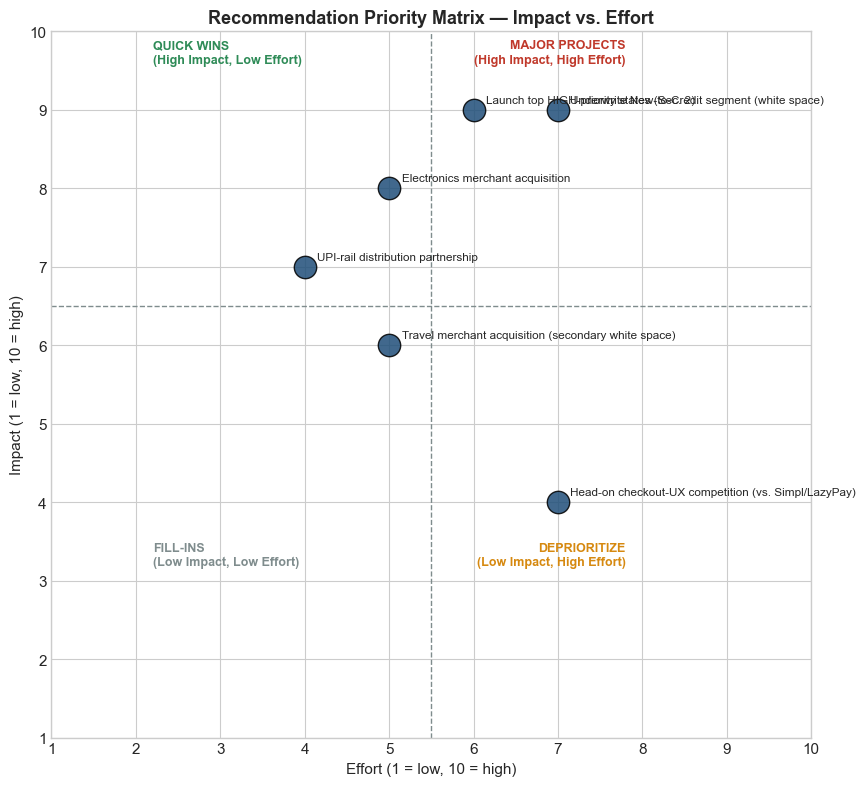

In [17]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(initiatives["Effort"], initiatives["Impact"], s=260, color=ACCENT, edgecolors="black", linewidth=1, alpha=0.85, zorder=3)

for _, row in initiatives.iterrows():
    ax.annotate(row["Initiative"], (row["Effort"], row["Impact"]),
                textcoords="offset points", xytext=(9, 5), fontsize=8.5, wrap=True)

ax.axvline(5.5, color=GREY, linestyle="--", linewidth=1)
ax.axhline(6.5, color=GREY, linestyle="--", linewidth=1)

ax.text(2.2, 9.6, "QUICK WINS\n(High Impact, Low Effort)", fontsize=9, fontweight="bold", color=ACCENT3)
ax.text(7.8, 9.6, "MAJOR PROJECTS\n(High Impact, High Effort)", fontsize=9, fontweight="bold", color=ACCENT2, ha="right")
ax.text(2.2, 3.2, "FILL-INS\n(Low Impact, Low Effort)", fontsize=9, fontweight="bold", color=GREY)
ax.text(7.8, 3.2, "DEPRIORITIZE\n(Low Impact, High Effort)", fontsize=9, fontweight="bold", color=ACCENT4, ha="right")

ax.set_xlim(1, 10)
ax.set_ylim(1, 10)
ax.set_xlabel("Effort (1 = low, 10 = high)")
ax.set_ylabel("Impact (1 = low, 10 = high)")
ax.set_title("Recommendation Priority Matrix — Impact vs. Effort")
plt.tight_layout()
plt.show()

**Business takeaway:** UPI-rail partnership is the clearest quick win (low effort, real impact) and should be sequenced first operationally, even though state launch and white-space underwriting carry more total impact — a nuance an interviewer will specifically probe: *"what do you do in month 1 vs. month 6."*

## 10. Risk Heatmap

**Methodology:** each risk scored 1-5 on Likelihood and Impact — qualitative judgment, logged as an assumption in Section 12. Heat = Likelihood x Impact.

In [18]:
risks = pd.DataFrame([
    {"Risk": "RBI regulatory tightening (FLDG/compliance)",        "Likelihood": 4, "Impact": 5},
    {"Risk": "Marketplace incumbents subsidize BNPL economics",     "Likelihood": 4, "Impact": 4},
    {"Risk": "Credit losses from New-to-Credit segment underwriting","Likelihood": 3, "Impact": 5},
    {"Risk": "NBFC funding-cost cycle raises unit economics cost",  "Likelihood": 3, "Impact": 4},
    {"Risk": "TAM sizing gap overstates opportunity (NB1, Sec 3.2)", "Likelihood": 3, "Impact": 4},
    {"Risk": "Merchant concentration in Electronics/Fashion only",  "Likelihood": 2, "Impact": 3},
    {"Risk": "Slower-than-expected digital adoption in Phase 2/3 states", "Likelihood": 3, "Impact": 3},
])
risks["Heat"] = risks["Likelihood"] * risks["Impact"]
risks.sort_values("Heat", ascending=False)

,Risk,Likelihood,Impact,Heat
0,RBI regulatory tightening (FLDG/compliance),4,5,20
1,Marketplace incumbents subsidize BNPL economics,4,4,16
2,Credit losses from New-to-Credit segment under...,3,5,15
3,NBFC funding-cost cycle raises unit economics ...,3,4,12
4,"TAM sizing gap overstates opportunity (NB1, Se...",3,4,12
6,Slower-than-expected digital adoption in Phase...,3,3,9
5,Merchant concentration in Electronics/Fashion ...,2,3,6


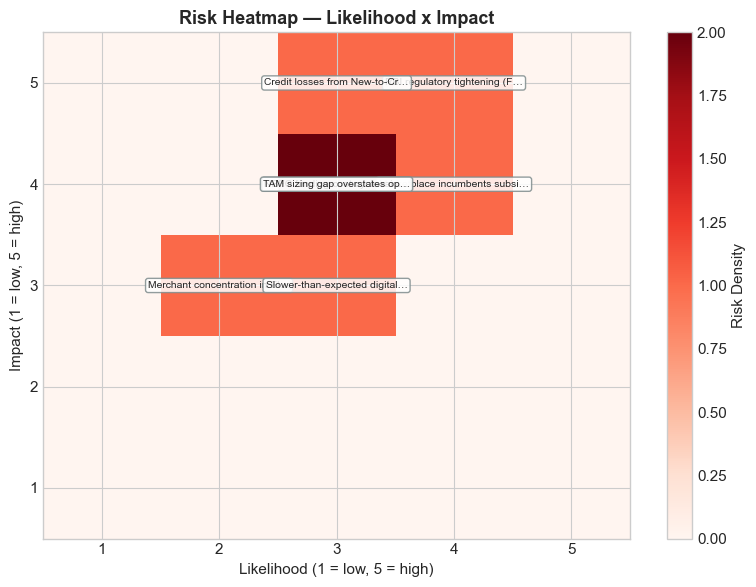

In [19]:
heat_matrix = risks.pivot_table(index="Risk", values="Heat", aggfunc="sum").reindex(
    risks.sort_values("Heat", ascending=False)["Risk"]
)

fig, ax = plt.subplots(figsize=(8, 6))
grid = np.zeros((5, 5))
for _, row in risks.iterrows():
    grid[row["Impact"]-1, row["Likelihood"]-1] += 1

im = ax.imshow(grid, cmap="Reds", origin="lower", extent=[0.5, 5.5, 0.5, 5.5], aspect="auto")

for _, row in risks.iterrows():
    ax.annotate(row["Risk"][:28] + ("…" if len(row["Risk"]) > 28 else ""),
                (row["Likelihood"], row["Impact"]), fontsize=7.5, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=GREY, alpha=0.85))

ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.set_xlabel("Likelihood (1 = low, 5 = high)")
ax.set_ylabel("Impact (1 = low, 5 = high)")
ax.set_title("Risk Heatmap — Likelihood x Impact")
plt.colorbar(im, ax=ax, label="Risk Density")
plt.tight_layout()
plt.show()

**Business takeaway:** the two highest-heat risks — regulatory tightening and credit losses on the New-to-Credit segment — are directly in tension with the strategy's core differentiation angle (Section 6/7). That tension is not a flaw in the recommendation; it is the trade-off to name explicitly in interview: the same segment that is the biggest whitespace opportunity is also the biggest credit-risk exposure, which is why Section 11 recommends phased underwriting exposure rather than an all-in launch.

## 11. CEO Recommendation

> ### Recommendation: Enter the India BNPL market with a segment-first strategy targeting New-to-Credit Users, sequenced through moderately concentrated (not saturated) competitive whitespace.
>
> **Why now:** HHI reads moderately concentrated (Section 4.2) — this market is contestable, not closed. Waiting increases regulatory compliance cost (Section 8) without reducing competitive intensity.
>
> **Where:** Launch in the top HIGH-priority states by population (Section 2), cross-checked against Notebook 1's Attractiveness Score for digital readiness and whitespace before final state selection.
>
> **Who:** Lead with the New-to-Credit Users segment — the only Very-High-priority customer segment and the clearest competitive white space (Section 6) — rather than competing head-on for Young Professionals, where Amazon Pay Later and Flipkart Pay Later already have merchant-ecosystem advantages.
>
> **What first (sequencing, Section 9):** UPI-rail distribution partnership as the quick win; Electronics merchant acquisition in parallel; New-to-Credit underwriting build as the highest-impact, higher-effort track running concurrently, not sequentially after launch.
>
> **Biggest risk to manage:** credit losses on New-to-Credit underwriting (Section 10) — the same segment driving the opportunity. Recommend phased underwriting exposure (limits ramp-up) rather than full-limit launch, to contain the highest-heat risk on the map.
>
> **What would change this recommendation:** if primary state-level digital-adoption or competitor segment-penetration data (flagged as assumptions in Section 12) comes in materially different from the proxies used here, the state sequencing and whitespace read should be re-run before committing capital.

## 12. Assumption Register

| # | Assumption | Used In | Value / Basis | Confidence | Replace With |
|---|---|---|---|---|---|
| 1 | HHI antitrust thresholds (US DOJ/FTC) applied as a directional concentration benchmark | HHI Interpretation (4.3) | <1,500 / 1,500-2,500 / >2,500 | Medium — standard heuristic, not India-specific regulatory guidance | India-specific market concentration benchmarks (CCI guidance) if available |
| 2 | Bajaj Finance excluded from HHI as EMI, not BNPL | HHI (4.2) | Type == "BNPL" filter | High — based on `Type` column already in source data | N/A — data-driven exclusion |
| 3 | Competitive Saturation Score per customer/merchant segment | White Space Matrix (6) | 1-4 scale, analyst-derived from competitor `Strength` positioning | Low — directional estimate, not measured | Competitor-disclosed segment penetration data (not publicly available) |
| 4 | Impact / Effort scores per initiative | Priority Matrix (9) | 1-10 scale, qualitative strategic judgment | Medium — reasoned but not empirically validated | Post-launch actuals (conversion cost, revenue lift) once available |
| 5 | Likelihood / Impact scores per risk | Risk Heatmap (10) | 1-5 scale, qualitative judgment | Medium — reasoned but not statistically modeled | Actuarial/credit-loss modeling once underwriting data exists |
| 6 | Bubble size = Users_M in Positioning Quadrant (5) | Positioning Quadrant (5) | Visualization choice only | High — reuses validated source columns, no new estimate | N/A |

**How to defend this in an interview:** anything in Sections 4.3, 6, 9, and 10 that isn't a direct pull from `../DATA/` traces to a row here. The answer to "is this real data" is either "yes, column X" or "no, it's a logged assumption — here's why it was scored that way." 

## 13. Executive Summary

In [20]:
TOP5_STATES = STATE_RANKING.head(5)["State"].tolist()
TOP_CUSTOMER_SEGMENT = CUSTOMER_SEGMENTS.loc[CUSTOMER_SEGMENTS["Priority"] == "Very High", "Segment"].tolist()
TOP_MERCHANT_SEGMENT = MERCHANT_SEGMENTS.loc[MERCHANT_SEGMENTS["Priority"] == "Very High", "Segment"].tolist()
TOP_RISK = risks.sort_values("Heat", ascending=False).iloc[0]["Risk"]

print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)
print("Recommended Launch States (top 5 by Opportunity Score):")
for s in TOP5_STATES:
    print(" -", s)
print()
print("Very-High Priority Customer Segment(s):", ", ".join(TOP_CUSTOMER_SEGMENT))
print("Very-High Priority Merchant Segment(s):", ", ".join(TOP_MERCHANT_SEGMENT))
print(f"Market Concentration (BNPL-only HHI)   : {HHI:,.0f} ({interp})")
print(f"Highest-Heat Risk                      : {TOP_RISK}")
print()
print("FINAL GTM RECOMMENDATION")
print("Phase 1: Launch in top HIGH-priority states; UPI-rail partnership (quick win)")
print("Phase 2: Electronics + Travel merchant acquisition; ramp New-to-Credit underwriting")
print("Phase 3: Expand to Tier 2 cities and remaining MEDIUM-priority states")
print()
print("Expected Outcome: Defensible entry into a moderately concentrated market via an")
print("underserved segment, with phased credit-risk exposure on the highest-heat risk identified.")

EXECUTIVE SUMMARY
Recommended Launch States (top 5 by Opportunity Score):
 - Uttar Pradesh
 - Bihar
 - Maharashtra
 - West Bengal
 - Madhya Pradesh

Very-High Priority Customer Segment(s): New-to-Credit Users
Very-High Priority Merchant Segment(s): Electronics
Market Concentration (BNPL-only HHI)   : 2,124 (Moderately concentrated market)
Highest-Heat Risk                      : RBI regulatory tightening (FLDG/compliance)

FINAL GTM RECOMMENDATION
Phase 1: Launch in top HIGH-priority states; UPI-rail partnership (quick win)
Phase 2: Electronics + Travel merchant acquisition; ramp New-to-Credit underwriting
Phase 3: Expand to Tier 2 cities and remaining MEDIUM-priority states

Expected Outcome: Defensible entry into a moderately concentrated market via an
underserved segment, with phased credit-risk exposure on the highest-heat risk identified.
